In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import common

SEED = 42


def set_seed(seed: int = 42) -> None:
    """난수 시드를 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.6.0+cu124, Device: cuda


In [2]:
data = common.load_data(path="data/BTC_3min_2024-10.csv")

print(f"data shape: {data.shape}")
data.head()

data shape: (13436, 9)


,open,high,low,close,volume,value,ma_3,ma_5,middle
2024-10-03 12:39:00,82505000.0,82505000.0,82427000.0,82505000.0,2.966659,2.447083e+08,8.253700e+07,82558400.0,82466000.0
2024-10-03 12:42:00,82500000.0,82505000.0,82423000.0,82499000.0,1.690431,1.393662e+08,8.249833e+07,82546000.0,82464000.0
2024-10-03 12:45:00,82499000.0,82593000.0,82433000.0,82482000.0,3.699225,3.052489e+08,8.249533e+07,82518400.0,82513000.0
2024-10-03 12:48:00,82590000.0,82591000.0,82500000.0,82589000.0,0.558138,4.609081e+07,8.252333e+07,82513200.0,82545500.0
2024-10-03 12:51:00,82590000.0,82610000.0,82540000.0,82609000.0,2.760618,2.280237e+08,8.256000e+07,82536800.0,82575000.0


In [3]:
MODEL_NAME = "LSTM Attention"

FEATURE_NUMS = 8
SEQ_LENGTH = 288
HIDDEN_DIM = 64
NUM_LAYERS = 2
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
NUM_WORKERS = 0

TRAIN_RATIO = 0.7
FIT_TRAIN_RATIO = 0.8

MAX_EPOCHS = 200
PATIENCE = 15

# 주의: 이 모델만 hidden_dim 64, 2층이라 다른 노트북(hidden 4, 1층)보다 용량이 훨씬 크다.
# 성능 차이에 아키텍처 효과와 용량 효과가 섞여 있으므로 해석할 때 감안해야 한다.

In [4]:
train_df, test_df = common.split_data(data, train_ratio=TRAIN_RATIO)
train_fit_df, val_df = common.split_data(train_df, train_ratio=FIT_TRAIN_RATIO)

# 스케일러는 실제 학습에 쓰는 구간에만 fit한다.
scaler_x, scaler_y = common.fit_scalers(train_fit_df, kind="minmax")

train_arr = common.apply_scalers(train_fit_df, scaler_x, scaler_y)
val_arr = common.apply_scalers(val_df, scaler_x, scaler_y)
test_arr = common.apply_scalers(test_df, scaler_x, scaler_y)

print(
    f"train_fit rows: {len(train_fit_df)}, "
    f"val rows: {len(val_df)}, "
    f"test rows: {len(test_df)}"
)

train_fit rows: 7524, val rows: 1881, test rows: 4031


In [5]:
x_train_data, y_train_data = common.make_sequences(
    train_arr, seq_length=SEQ_LENGTH, n_features=FEATURE_NUMS
)
x_val_data, y_val_data = common.make_sequences(
    val_arr, seq_length=SEQ_LENGTH, n_features=FEATURE_NUMS
)
x_test_data, y_test_data = common.make_sequences(
    test_arr, seq_length=SEQ_LENGTH, n_features=FEATURE_NUMS
)

# test_df는 split_data가 돌려준 원 단위 DataFrame이다.
naive_test_raw = common.naive_baseline_from_df(test_df, SEQ_LENGTH)

expected_train_samples = len(train_fit_df) - SEQ_LENGTH
expected_val_samples = len(val_df) - SEQ_LENGTH
expected_test_samples = len(test_df) - SEQ_LENGTH

if min(expected_train_samples, expected_val_samples, expected_test_samples) <= 0:
    raise ValueError("SEQ_LENGTH보다 각 구간의 행 수가 충분히 커야 합니다.")

if x_train_data.shape[0] != expected_train_samples or y_train_data.shape[0] != expected_train_samples:
    raise ValueError("학습 시퀀스 표본 수가 train_fit_df와 맞지 않습니다.")

if x_val_data.shape[0] != expected_val_samples or y_val_data.shape[0] != expected_val_samples:
    raise ValueError("검증 시퀀스 표본 수가 val_df와 맞지 않습니다.")

if x_test_data.shape[0] != expected_test_samples or y_test_data.shape[0] != expected_test_samples:
    raise ValueError("테스트 시퀀스 표본 수가 test_df와 맞지 않습니다.")

if naive_test_raw.shape != y_test_data.shape:
    raise ValueError("원 단위 naive 기준선과 최종 테스트 타깃의 표본 수가 맞지 않습니다.")

print(f"train samples: {x_train_data.shape[0]}")
print(f"val samples: {x_val_data.shape[0]}")
print(f"test samples: {x_test_data.shape[0]}")

train samples: 7236
val samples: 1593
test samples: 3743


In [6]:
train_dataset = TensorDataset(
    torch.from_numpy(x_train_data).float(), torch.from_numpy(y_train_data).float()
)
val_dataset = TensorDataset(
    torch.from_numpy(x_val_data).float(), torch.from_numpy(y_val_data).float()
)
test_dataset = TensorDataset(
    torch.from_numpy(x_test_data).float(), torch.from_numpy(y_test_data).float()
)

# 시계열이므로 학습 배치도 셔플하지 않는다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

In [7]:
class Attention(nn.Module):
    """시간축 attention. softmax를 seq 축(dim=1)에서 정규화한다.

    원본의 FeatureAttention은 softmax를 hidden_dim(64) 축에서 정규화하고
    그 64개 중 앞 8개를 잘라 입력 피처 이름을 붙였다. 은닉 유닛을 피처로 오인한 것이라
    해석이 성립하지 않아 삭제했다.
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_outputs):
        scores = self.score(lstm_outputs)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_outputs, dim=1)
        return context, weights


class MyLSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.attention = Attention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_dim)
        c0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_dim)

        lstm_outputs, _ = self.lstm(x, (h0, c0))
        context, weights = self.attention(lstm_outputs)
        return self.fc(context), weights

In [8]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.01)


set_seed(SEED)

model = MyLSTMAttentionModel(FEATURE_NUMS, HIDDEN_DIM, NUM_LAYERS).to(DEVICE)
model.apply(init_weights)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

MyLSTMAttentionModel(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True)
  (attention): Attention(
    (score): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [9]:
def run_epoch(dataloader, model, loss_function, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    loss_sum = 0.0
    sample_count = 0

    with torch.set_grad_enabled(is_train):
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
            labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            outputs, _ = model(inputs)
            loss = loss_function(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = inputs.size(0)
            loss_sum += loss.item() * batch_size
            sample_count += batch_size

    if sample_count == 0:
        raise ValueError("DataLoader에 평가할 표본이 없습니다.")

    return loss_sum / sample_count


def predict(dataloader, model):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
            outputs, _ = model(inputs)

            predictions.append(outputs.detach().cpu().numpy())
            targets.append(labels.detach().cpu().numpy())

    if not predictions:
        raise ValueError("테스트 예측 표본이 없습니다.")

    return np.concatenate(predictions, axis=0), np.concatenate(targets, axis=0)


def collect_attention_weights(dataloader, model):
    """테스트셋 전체의 시간축 attention 가중치를 모은다."""
    model.eval()
    weights_list = []

    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
            _, weights = model(inputs)
            weights_list.append(weights.detach().cpu().numpy())

    if not weights_list:
        raise ValueError("attention 가중치 표본이 없습니다.")

    return np.concatenate(weights_list, axis=0)

In [10]:
train_loss_list = []
val_loss_list = []

best_val_loss = float("inf")
best_state = None
best_epoch = 0
stale_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, loss_function, optimizer)
    val_loss = run_epoch(val_loader, model, loss_function)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        stale_epochs = 0
    else:
        stale_epochs += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch [{epoch}/{MAX_EPOCHS}] train_loss={train_loss:.8f}, val_loss={val_loss:.8f}")

    if stale_epochs >= PATIENCE:
        print(f"early stopping: epoch={epoch}, patience={PATIENCE}")
        break

if best_state is None:
    raise RuntimeError("최고 검증 손실 가중치를 저장하지 못했습니다.")

model.load_state_dict(best_state)

print(f"{MODEL_NAME} best epoch: {best_epoch}, best val loss: {best_val_loss:.8f}")

Epoch [1/200] train_loss=0.00591842, val_loss=0.00197395


Epoch [10/200] train_loss=0.00266466, val_loss=0.00744791


early stopping: epoch=16, patience=15
LSTM Attention best epoch: 1, best val loss: 0.00197395


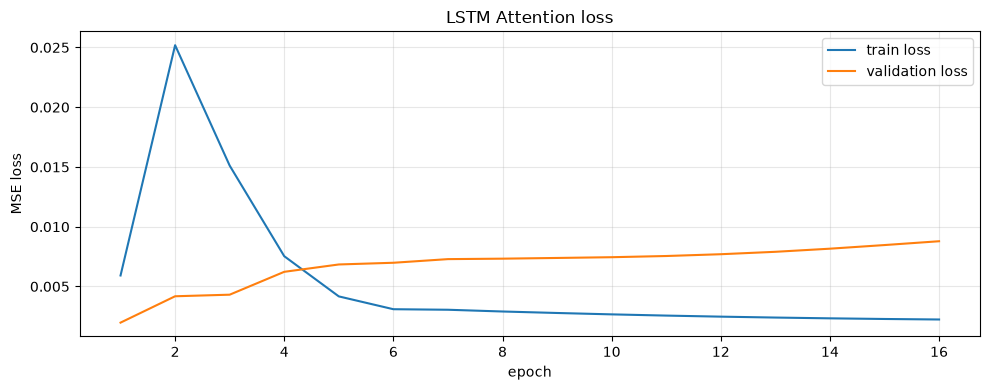

In [11]:
epochs = np.arange(1, len(train_loss_list) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, train_loss_list, label="train loss")
plt.plot(epochs, val_loss_list, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title(f"{MODEL_NAME} loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
test_pred_scaled, y_test_scaled = predict(test_loader, model)

pred_inverse = scaler_y.inverse_transform(test_pred_scaled)
y_test_inverse = scaler_y.inverse_transform(y_test_scaled)

if pred_inverse.shape != y_test_inverse.shape:
    raise ValueError("원 단위 예측과 원 단위 타깃의 표본 수가 맞지 않습니다.")

if pred_inverse.shape != naive_test_raw.shape:
    raise ValueError("모델 예측과 원 단위 naive 기준선의 표본 수가 맞지 않습니다.")

# 임의 구간이 아니라 테스트셋 전체에서, naive 기준선과 같은 표본으로 평가한다.
result = common.compare_to_naive(
    model_pred=pred_inverse,
    naive_pred=naive_test_raw,
    true=y_test_inverse,
    name=MODEL_NAME,
    unit="원",
)
common.save_result(result)

print(f"naive 대비 MAE 배수: {result['mae_ratio']:.3f}  (1보다 크면 naive보다 나쁨)")
common.report_table([result])

naive 대비 MAE 배수: 64.403  (1보다 크면 naive보다 나쁨)


,모델,MAE,RMSE,MAPE(%),naive대비MAE배수,모델이naive를이김
0,LSTM Attention,2.485686e+06,3.404780e+06,2.5222,64.4032,False


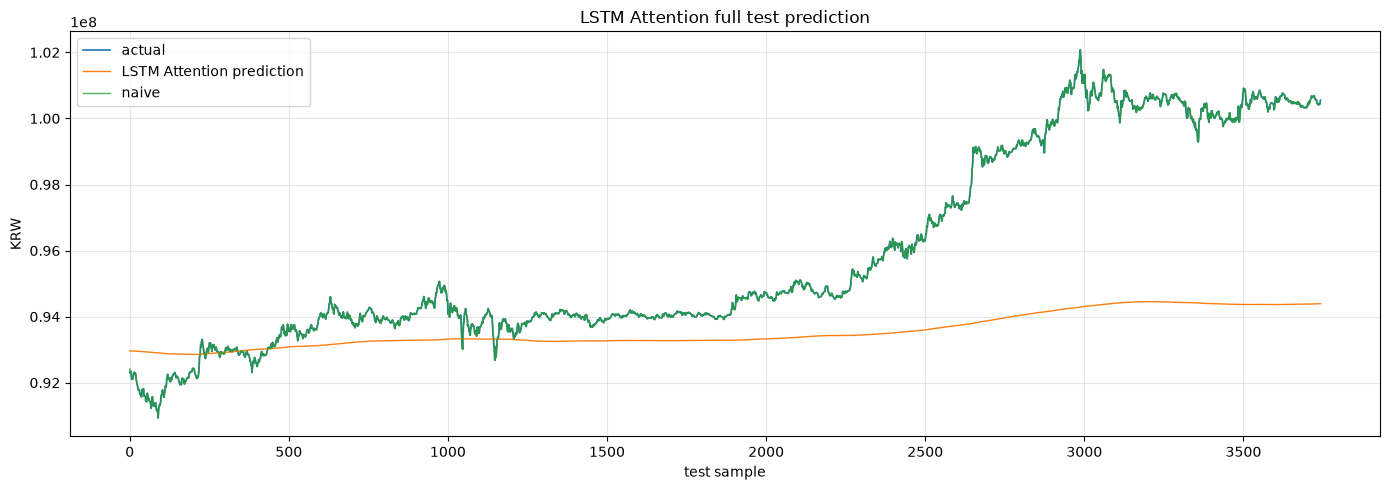

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_inverse.reshape(-1), label="actual", linewidth=1.2)
plt.plot(pred_inverse.reshape(-1), label=f"{MODEL_NAME} prediction", linewidth=1.0)
plt.plot(naive_test_raw.reshape(-1), label="naive", linewidth=1.0, alpha=0.8)
plt.xlabel("test sample")
plt.ylabel("KRW")
plt.title(f"{MODEL_NAME} full test prediction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

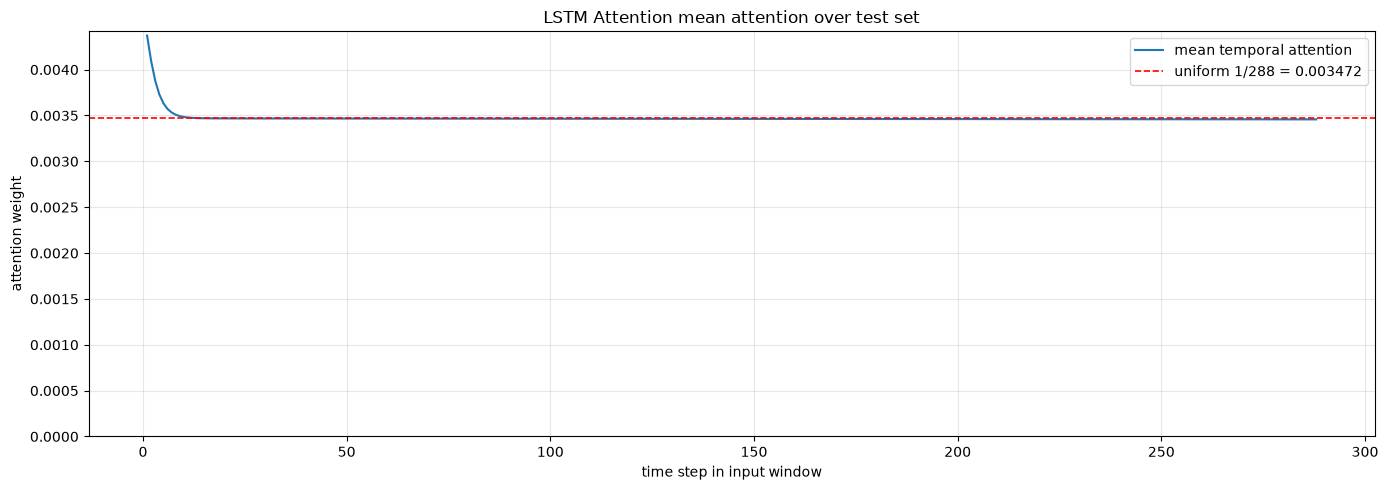

균일 가중치 0.003472 대비 최대 0.004372, 최소 0.003457
최대/균일 비율: 1.26배


In [14]:
attention_weights = collect_attention_weights(test_loader, model)

if attention_weights.shape != (y_test_data.shape[0], SEQ_LENGTH, 1):
    raise ValueError("attention 가중치 형태가 테스트 시퀀스와 맞지 않습니다.")

# 표본 1개가 아니라 테스트셋 전체 평균을 본다.
mean_attention = attention_weights.mean(axis=0).reshape(-1)
uniform_weight = 1.0 / SEQ_LENGTH
time_steps = np.arange(1, SEQ_LENGTH + 1)

plt.figure(figsize=(14, 5))
plt.plot(time_steps, mean_attention, label="mean temporal attention", linewidth=1.5)
plt.axhline(uniform_weight, color="red", linestyle="--", linewidth=1.2,
            label=f"uniform 1/{SEQ_LENGTH} = {uniform_weight:.6f}")
# y축을 0부터 잡는다. 원본은 폭 0.0005로 확대해 균일한 가중치를 구조처럼 보이게 했다.
plt.ylim(bottom=0.0)
plt.xlabel("time step in input window")
plt.ylabel("attention weight")
plt.title(f"{MODEL_NAME} mean attention over test set")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"균일 가중치 {uniform_weight:.6f} 대비 최대 {mean_attention.max():.6f}, 최소 {mean_attention.min():.6f}")
print(f"최대/균일 비율: {mean_attention.max() / uniform_weight:.2f}배")